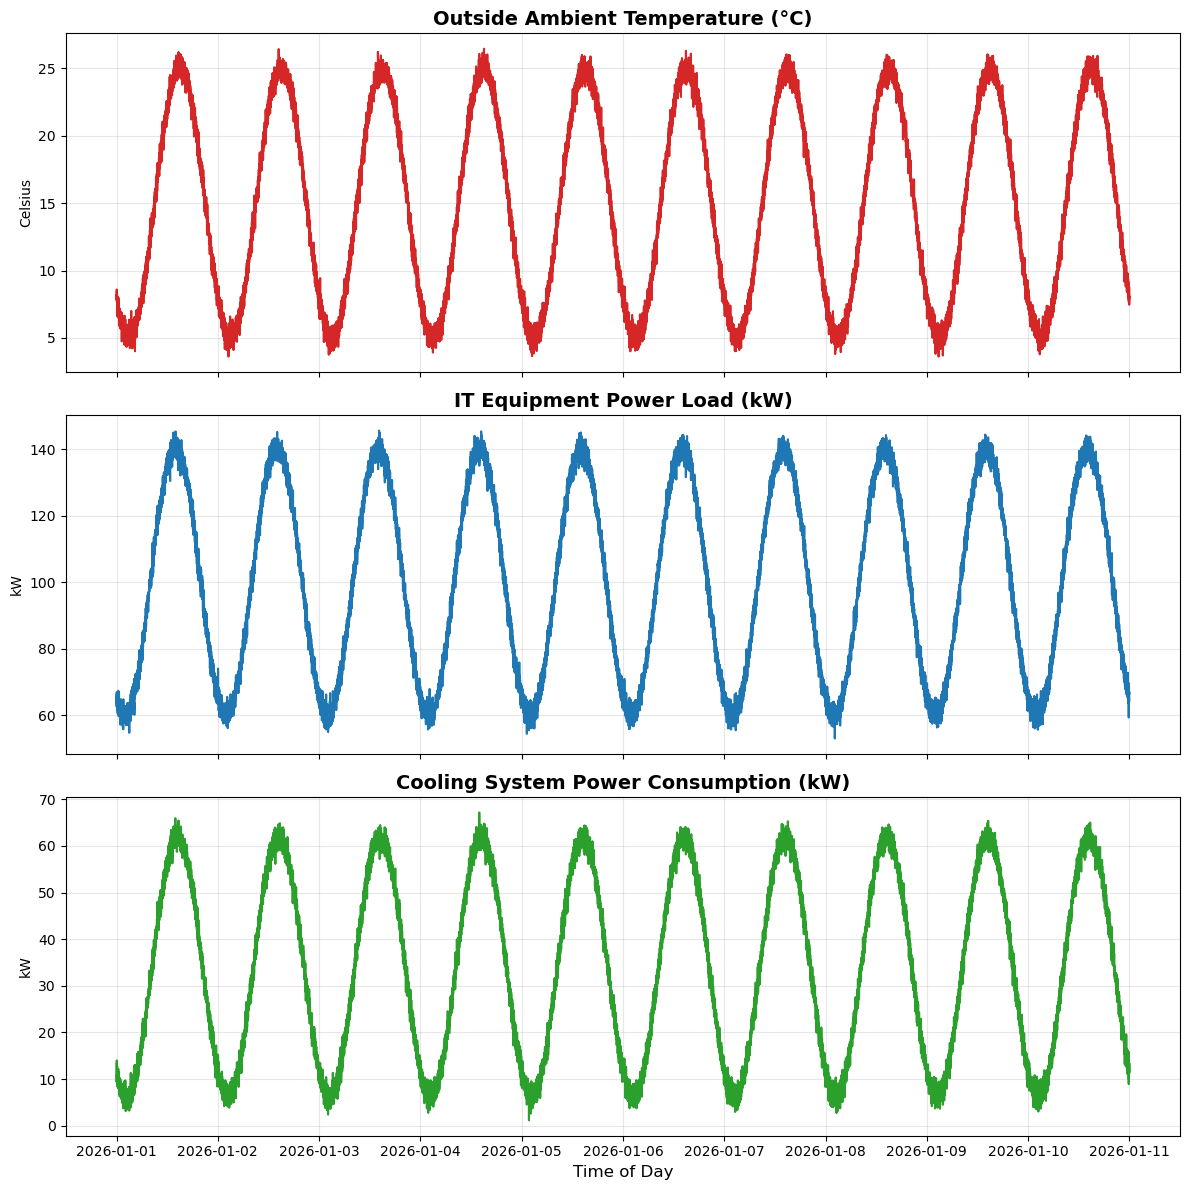

In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def generate_dc_data(days=5): # Increased days for more training samples
    np.random.seed(42)
    time_index = pd.date_range(start="2026-01-01", periods=1440*days, freq='min')
    n = len(time_index)
    t_hours = np.arange(n) / 60
    
    temp_outside = 15 + 10 * np.sin(np.pi * (t_hours - 9) / 12) + np.random.normal(0, 0.5, n)
    it_load_kw = 100 + 40 * np.sin(np.pi * (t_hours - 8) / 12) + np.random.normal(0, 2, n)
    cooling_power_kw = (0.4 * it_load_kw) + (1.2 * (temp_outside - 20)) + np.random.normal(0, 1, n)
    
    return pd.DataFrame({
        'Timestamp': time_index,
        'Ambient_Temp_C': temp_outside,
        'IT_Load_kW': it_load_kw,
        'Cooling_Power_kW': cooling_power_kw
    })

fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

axes[0].plot(df['Timestamp'], df['Ambient_Temp_C'], color='tab:red', label='Ambient Temp')
axes[0].set_title('Outside Ambient Temperature (°C)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Celsius')
axes[0].grid(True, alpha=0.3)

axes[1].plot(df['Timestamp'], df['IT_Load_kW'], color='tab:blue', label='Server Load')
axes[1].set_title('IT Equipment Power Load (kW)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('kW')
axes[1].grid(True, alpha=0.3)

axes[2].plot(df['Timestamp'], df['Cooling_Power_kW'], color='tab:green', label='Cooling Power')
axes[2].set_title('Cooling System Power Consumption (kW)', fontsize=14, fontweight='bold')
axes[2].set_ylabel('kW')
axes[2].grid(True, alpha=0.3)

plt.xlabel('Time of Day', fontsize=12)
plt.tight_layout()
plt.show()

Training on multi-sensor data...
Epoch 0: Loss = 1.0747
Epoch 50: Loss = 0.0406
Epoch 100: Loss = 0.0283
Epoch 150: Loss = 0.0242
Epoch 200: Loss = 0.0168
Epoch 250: Loss = 0.0140


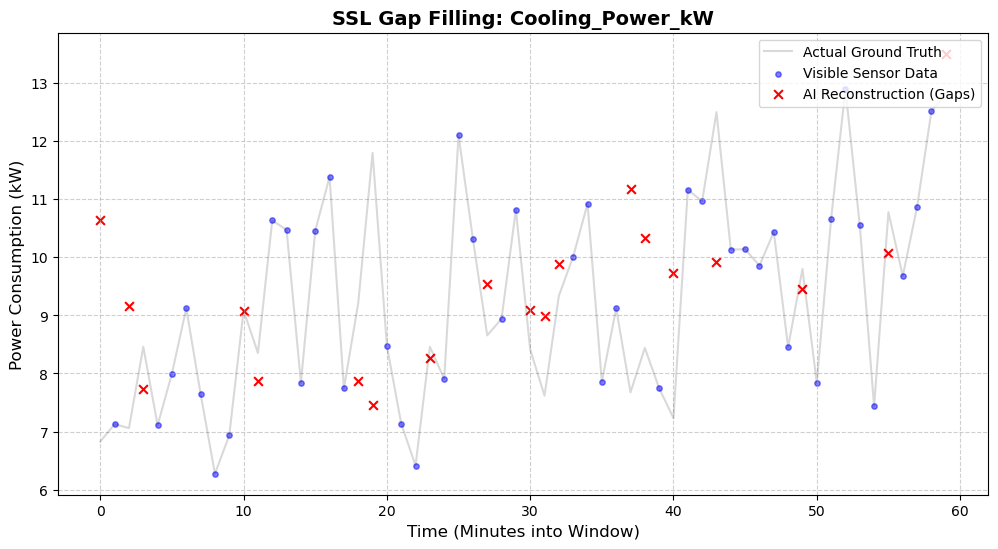

In [9]:
df = generate_dc_data(days=7)
features = ['Ambient_Temp_C', 'IT_Load_kW', 'Cooling_Power_kW']

data_val = df[features].values
mean, std = data_val.mean(axis=0), data_val.std(axis=0)
data_norm = (data_val - mean) / std

def create_windows(data, window_size=60): # 60 minute windows
    windows = []
    for i in range(len(data) - window_size):
        windows.append(data[i : i + window_size])
    return torch.tensor(np.array(windows), dtype=torch.float32)

WINDOW_SIZE = 60 
X_windows = create_windows(data_norm, WINDOW_SIZE)

# CNN
class MultiVariate_SSL(nn.Module):
    def __init__(self, num_features):
        super().__init__()
        # Input: (Batch, Features, Length)
        self.encoder = nn.Sequential(
            nn.Conv1d(num_features, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.ReLU()
        )
        self.decoder = nn.Conv1d(128, num_features, kernel_size=3, padding=1)
    
    def forward(self, x):
        x = x.permute(0, 2, 1) # To (B, C, L)
        x = self.encoder(x)
        x = self.decoder(x)
        return x.permute(0, 2, 1) # Back to (B, L, C)

model = MultiVariate_SSL(num_features=len(features))
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

# Loop
epochs = 300
batch_size = 64

print("Training on multi-sensor data...")
for epoch in range(epochs):
    indices = torch.randint(0, X_windows.size(0), (batch_size,))
    batch = X_windows[indices]
    
    # 25% Masking
    mask = torch.rand(batch.shape) > 0.25
    masked_input = batch * mask
    
    prediction = model(masked_input)
    loss = criterion(prediction[~mask], batch[~mask])
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if epoch % 50 == 0:
        print(f"Epoch {epoch}: Loss = {loss.item():.4f}")

# Plot
model.eval()
with torch.no_grad():
    sample_idx = np.random.randint(0, len(X_windows))
    test_sample = X_windows[sample_idx:sample_idx+1]
    test_mask = torch.rand(test_sample.shape) > 0.25
    
    recon = model(test_sample * test_mask)
    
    # Target feature index 2 is 'Cooling_Power_kW'
    feat_idx = 2
    gt = (test_sample[0, :, feat_idx].numpy() * std[feat_idx]) + mean[feat_idx]
    pred = (recon[0, :, feat_idx].numpy() * std[feat_idx]) + mean[feat_idx]
    m_flat = test_mask[0, :, feat_idx].numpy()

plt.figure(figsize=(12, 6))

plt.plot(gt, 'k-', alpha=0.15, label='Actual Ground Truth')

plt.scatter(np.where(m_flat)[0], gt[m_flat], color='blue', s=15, alpha=0.5, label='Visible Sensor Data')

plt.scatter(np.where(~m_flat)[0], pred[~m_flat], color='red', marker='x', s=40, label='AI Reconstruction (Gaps)')

plt.title(f"SSL Gap Filling: {features[feat_idx]}", fontsize=14, fontweight='bold')
plt.xlabel("Time (Minutes into Window)", fontsize=12)
plt.ylabel("Power Consumption (kW)", fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()